# Task 1: Exploring and Visualizing a Simple Dataset

**Objective:** Load, inspect, and visualize the Iris dataset to understand data trends and distributions.

**Dataset:** Iris Dataset (loaded via seaborn)

**Skills practiced:** data loading & inspection with pandas, descriptive statistics, and plotting with matplotlib/seaborn.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Dataset

We load the Iris dataset directly using seaborn's built-in loader (no manual CSV download needed).

In [2]:
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 3. Inspect Shape and Column Names

In [3]:
print("Shape of dataset (rows, columns):", df.shape)
print("\nColumn names:", list(df.columns))
print("\nSamples per Species:", df['species'].value_counts())

Shape of dataset (rows, columns): (150, 5)

Column names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

Samples per Species: species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


**Observation:** The dataset has **150 rows and 5 columns** — four numeric features (`sepal_length`, `sepal_width`, `petal_length`, `petal_width`, all in cm) and one categorical target column, `species`, with three classes (*setosa*, *versicolor*, *virginica*). With exactly 50 samples per species, the dataset is perfectly balanced.

## 4. First Few Rows

In [4]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 5. Dataset Info

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


**Observation:** All 150 entries are non-null across every column, so there is no missing data to clean. Four columns are `float64` (the measurements) and one is `object` (the species label), confirming the dataset is already in a tidy, analysis-ready format.

## 6. Summary Statistics

In [6]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


**Observation:** Petal measurements show far more spread than sepal measurements — `petal_length` ranges from 1.0 to 6.9 cm versus `sepal_length`'s narrower 4.3–7.9 cm range. This wider range hints that petal dimensions vary more between species and may be more useful for distinguishing them, which we'll confirm visually below.

## 7. Summary Statistics Grouped by Species

In [7]:
df.groupby('species').describe().T

species                setosa  versicolor  virginica
sepal_length count  50.000000   50.000000  50.000000
             mean    5.006000    5.936000   6.588000
             std     0.352490    0.516171   0.635880
             min     4.300000    4.900000   4.900000
             25%     4.800000    5.600000   6.225000
             50%     5.000000    5.900000   6.500000
             75%     5.200000    6.300000   6.900000
             max     5.800000    7.000000   7.900000
sepal_width  count  50.000000   50.000000  50.000000
             mean    3.428000    2.770000   2.974000
             std     0.379064    0.313798   0.322497
             min     2.300000    2.000000   2.200000
             25%     3.200000    2.525000   2.800000
             50%     3.400000    2.800000   3.000000
             75%     3.675000    3.000000   3.175000
             max     4.400000    3.400000   3.800000
petal_length count  50.000000   50.000000  50.000000
             mean    1.462000    4.260000   5.552000
             std     0.173664    0.469911   0.551895
             min     1.000000    3.000000   4.500000
             25%     1.400000    4.000000   5.100000
             50%     1.500000    4.350000   5.550000
             75%     1.575000    4.600000   5.875000
             max     1.900000    5.100000   6.900000
petal_width  count  50.000000   50.000000  50.000000
             mean    0.246000    1.326000   2.026000
             std     0.105386    0.197753   0.274650
             min     0.100000    1.000000   1.400000
             25%     0.200000    1.200000   1.800000
             50%     0.200000    1.300000   2.000000
             75%     0.300000    1.500000   2.300000
             max     0.600000    1.800000   2.500000

**Observation:** Splitting by species reveals clear separation: *setosa* has a notably smaller mean petal length (~1.46 cm) than *versicolor* (~4.26 cm) and *virginica* (~5.55 cm), with little overlap in their ranges. This strongly suggests petal length alone could classify *setosa* from the other two species almost perfectly.

## 8. Scatter Plot — Feature Relationships

We plot petal length vs. petal width, colored by species, to see how well the classes separate.

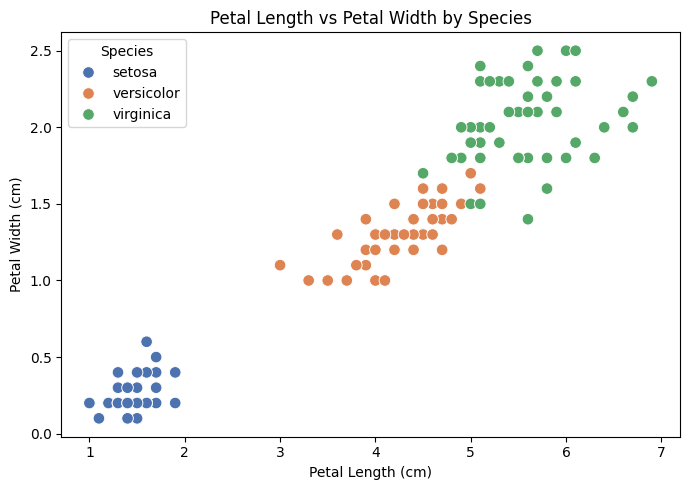

In [8]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species', s=70, palette='deep')
plt.title('Petal Length vs Petal Width by Species')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(title='Species')
plt.tight_layout()
plt.show()

**What this shows:** The three species form distinct, well-separated clusters, with *setosa* (bottom-left) completely isolated from the other two. There is a clear positive linear relationship between petal length and petal width — as one increases, so does the other — and *versicolor* and *virginica* show a small amount of overlap at the boundary between them, which is the only place a simple classifier would likely make mistakes.

## 9. Pairplot — All Feature Relationships at Once

To see every pairwise relationship in one view, we use seaborn's `pairplot`.

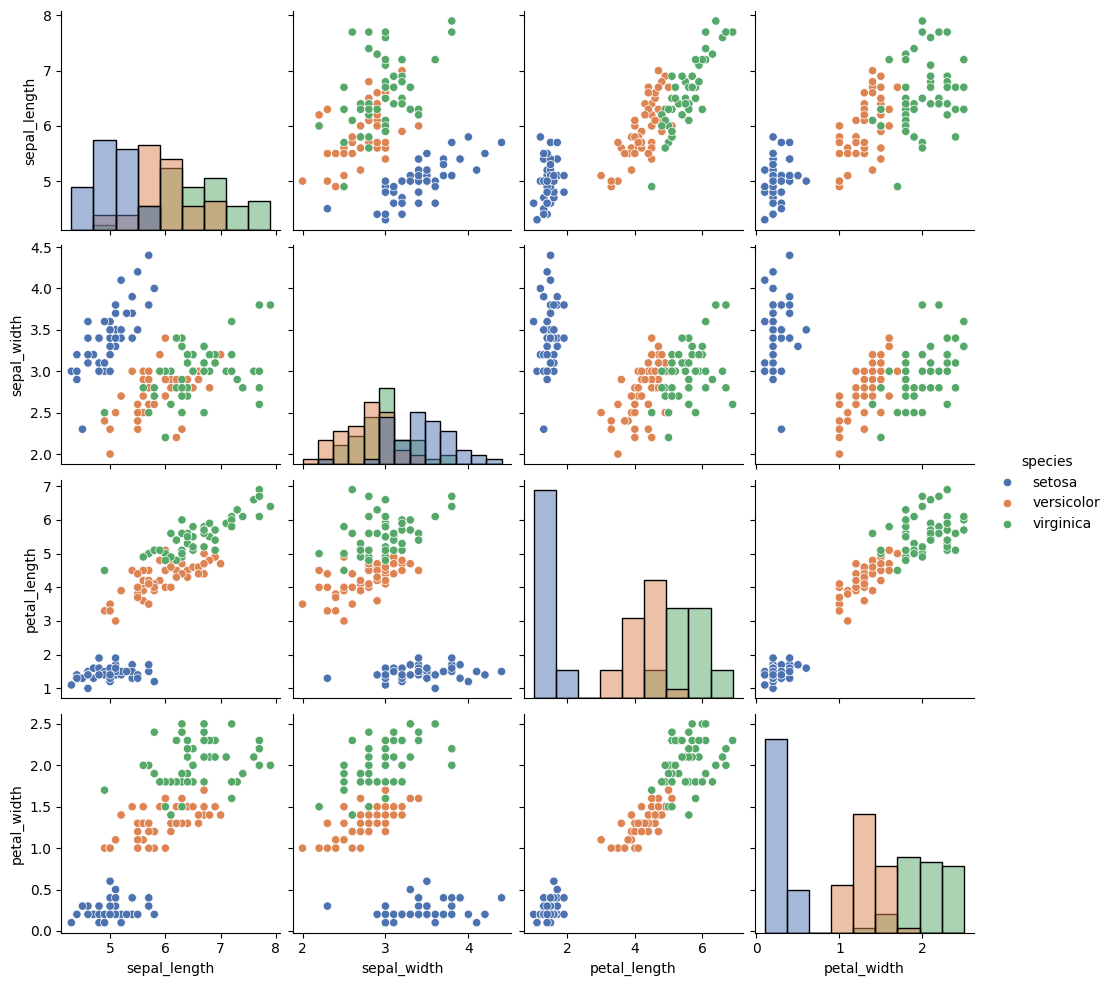

In [9]:
sns.pairplot(df, hue='species', palette='deep', diag_kind='hist')
plt.show()

**What this shows:** Across nearly every pair of features, *setosa* (blue) separates cleanly from the other two species, while *versicolor* and *virginica* overlap somewhat, especially on sepal measurements. Petal length and petal width consistently give the cleanest separation between all three species, reinforcing that these two features are the most discriminative for classification tasks.

## 10. Histograms — Value Distributions

We look at the distribution of each numeric feature.

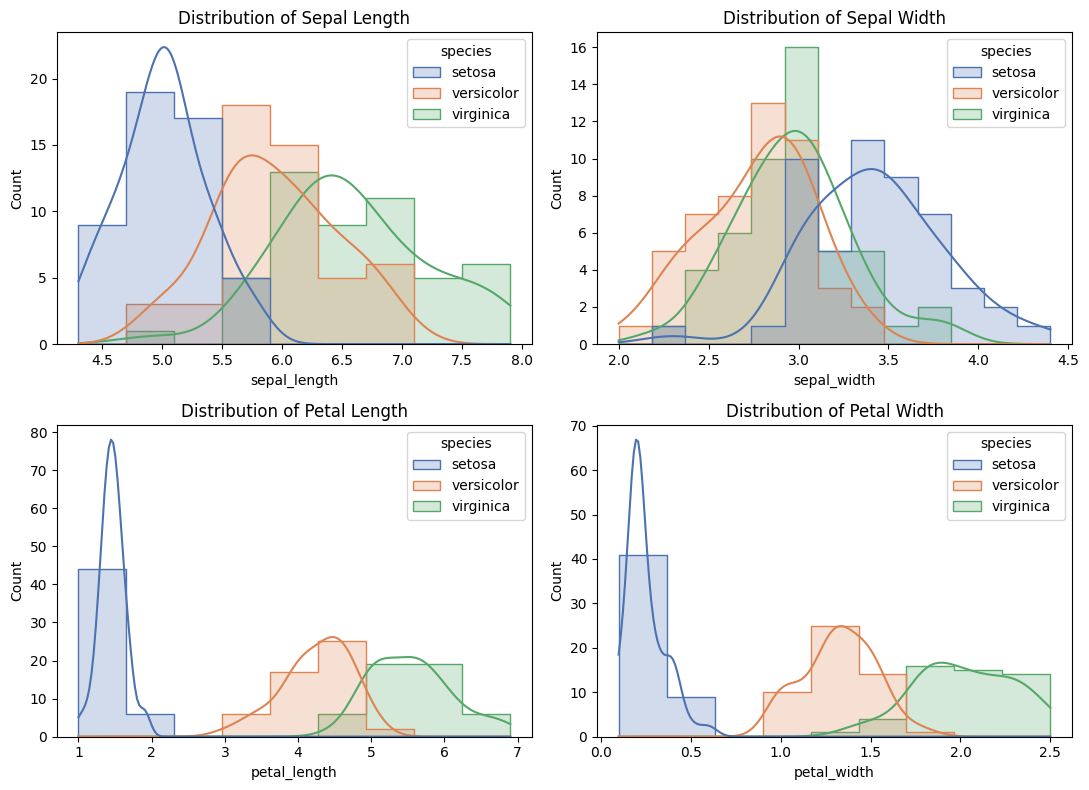

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

for ax, feature in zip(axes.flatten(), features):
    sns.histplot(data=df, x=feature, hue='species', kde=True, ax=ax, palette='deep', element='step')
    ax.set_title(f'Distribution of {feature.replace("_", " ").title()}')

plt.tight_layout()
plt.show()

**What this shows:** `sepal_width` looks roughly normal/bell-shaped and is the most overlapping feature across species, making it the least useful for telling species apart on its own. In contrast, `petal_length` and `petal_width` are clearly multi-modal once split by species — *setosa* forms a tight, separate peak far from *versicolor* and *virginica* — which visually confirms why petal measurements are stronger predictors of species than sepal measurements.

## 11. Box Plots — Identifying Outliers

Box plots help us spot outliers and compare spread across species for each feature.

/tmp/ipykernel_13313/3120309040.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feature, ax=ax, palette='deep')
/tmp/ipykernel_13313/3120309040.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feature, ax=ax, palette='deep')
/tmp/ipykernel_13313/3120309040.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feature, ax=ax, palette='deep')
/tmp/ipykernel_13313/3120309040.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remo

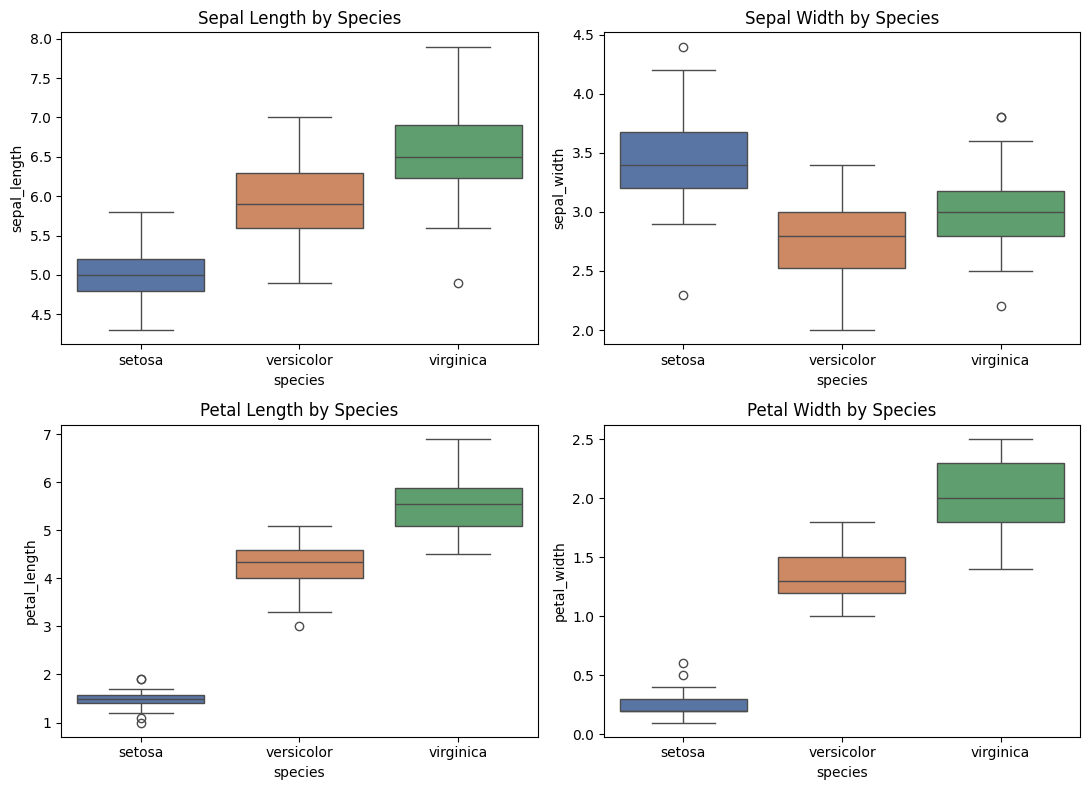

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(data=df, x='species', y=feature, ax=ax, palette='deep')
    ax.set_title(f'{feature.replace("_", " ").title()} by Species')

plt.tight_layout()
plt.show()

**What this shows:** Most features show tight, well-defined boxes with only a handful of mild outliers (small circles beyond the whiskers), most noticeably one or two points in `sepal_width` for *setosa* and `petal_length`/`petal_width` for *virginica*. The boxes for *setosa* sit clearly apart from the other two species on petal measurements with no overlap, while *versicolor* and *virginica* boxes are closer together and partially overlap, again pointing to those two species being harder to distinguish than *setosa*.

## 12. Bonus: Correlation Heatmap

As an extra exploration step, we examine how strongly the numeric features correlate with one another.

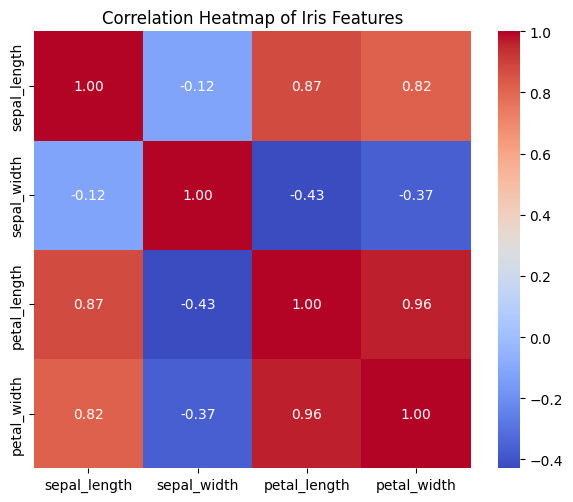

In [12]:
plt.figure(figsize=(6, 5))
numeric_df = df.drop(columns='species')
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Heatmap of Iris Features')
plt.tight_layout()
plt.show()

**What this shows:** Petal length and petal width are very strongly correlated (around 0.96), confirming the tight linear relationship seen in the scatter plot. Sepal width stands out as the odd feature out, showing weak or even slightly negative correlation with the other three measurements, which matches its poor species-separating power observed in the histograms and box plots above.

## 13. Summary of Findings

- The dataset is clean, balanced (50 samples per species), and has no missing values.
- **Petal length and petal width** are the most informative features for distinguishing species — *setosa* is linearly separable from the other two on these features alone.
- **Sepal width** is the least discriminative feature, with heavily overlapping distributions across species.
- *Versicolor* and *virginica* are the two species most likely to be confused with each other, since their feature distributions overlap the most.
- A small number of mild outliers exist but are not extreme enough to require removal for typical exploratory or modeling purposes.